# Veri Bilimi için 3 Kütüphane: Sweetviz, PyCaret, SHAP

Bu notebook'ta tek bir veri seti üzerinde veri bilimi sürecinin üç adımını görüyoruz:

1. **Sweetviz**: veriyi tanı (EDA)
2. **PyCaret**: modeli kur, karşılaştır, ayarla, kaydet
3. **SHAP**: model neden bu tahmini yaptı, onu anla

Veri seti olarak **Titanic** kullanıyoruz. Amacımız bir yolcunun hayatta kalıp kalmadığını (`Survived`) tahmin etmek.

> **Önemli:** PyCaret 3.3 yalnızca **Python 3.9, 3.10 ve 3.11** sürümlerini destekliyor. Python 3.12 veya daha yeni bir sürümdeysen önce 3.11 ile bir sanal ortam kur. Kurulum adımları README dosyasında.

## 0. Kurulum ve veri

In [1]:
# İlk çalıştırmada yorum satırını kaldır
# !pip install -r requirements.txt
# veya: !pip install pycaret sweetviz shap 'lightgbm<4.7'

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Model için anlamsız olan kimlik sütunlarını çıkarıyoruz
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 1. Sweetviz: İki satırla EDA

`analyze()` bütün sütunları, eksik değerleri, dağılımları ve **target ile ilişkileri** tek bir HTML raporda gösteriyor.

In [3]:
import sweetviz as sv

rapor = sv.analyze(df, target_feat="Survived")
rapor.show_html("sweetviz_rapor.html", open_browser=False)
# Notebook içinde görmek için: rapor.show_notebook()

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_rapor.html was generated.


### Bonus: Train ve test setini karşılaştır

`compare()` iki veri setini yan yana koyuyor. Train ve test dağılımları farklıysa model canlıda beklediğin gibi çalışmaz.

In [4]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Survived"])

karsilastirma = sv.compare([train, "Train"], [test, "Test"], target_feat="Survived")
karsilastirma.show_html("sweetviz_train_vs_test.html", open_browser=False)

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_train_vs_test.html was generated.


## 2. PyCaret: Birkaç satırla uçtan uca model

Aşağıdaki dört fonksiyon normalde yüzlerce satır sürecek bir işi yapıyor:

| Fonksiyon | Ne yapar |
|---|---|
| `setup()` | Eksik değer doldurma, kategorik kodlama, train/test ayrımı |
| `compare_models()` | Bütün modelleri cross-validation ile eğitir, skora göre sıralar |
| `tune_model()` | Hiperparametre ayarı |
| `save_model()` | Ön işleme + modeli tek dosya olarak kaydeder |

In [5]:
from pycaret.classification import (
    setup, compare_models, create_model, tune_model,
    plot_model, predict_model, finalize_model, save_model, get_config,
)

s = setup(data=train, target="Survived", session_id=42, verbose=False)

In [6]:
# Bütün modelleri eğitip Accuracy'ye göre sırala
en_iyi = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8274,0.8702,0.7024,0.8391,0.7565,0.6250,0.6377,0.0170
rf,Random Forest Classifier,0.8073,0.8502,0.7226,0.7705,0.7422,0.5888,0.5931,0.0260
ridge,Ridge Classifier,0.7972,0.8520,0.6918,0.7625,0.7214,0.5633,0.5685,0.0080
lda,Linear Discriminant Analysis,0.7972,0.8522,0.6971,0.7584,0.7227,0.5640,0.5686,0.0070
lightgbm,Light Gradient Boosting Machine,0.7972,0.8573,0.7021,0.7643,0.7267,0.5665,0.5726,0.0570
ada,Ada Boost Classifier,0.7971,0.8437,0.7334,0.7504,0.7350,0.5714,0.5783,0.0150
lr,Logistic Regression,0.7892,0.8503,0.6971,0.7424,0.7144,0.5484,0.5532,0.2970
et,Extra Trees Classifier,0.7791,0.8265,0.7118,0.7176,0.7120,0.5330,0.5355,0.0250
nb,Naive Bayes,0.7733,0.8084,0.6924,0.7066,0.6957,0.5161,0.5194,0.0080
dt,Decision Tree Classifier,0.7589,0.7482,0.6911,0.6903,0.6870,0.4913,0.4950,0.0080


In [7]:
# En iyi modelin hiperparametrelerini ayarla
ayarli = tune_model(en_iyi)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7800,0.8367,0.6000,0.8000,0.6857,0.5217,0.5345
1,0.7600,0.8370,0.6316,0.7059,0.6667,0.4801,0.4819
2,0.8200,0.8031,0.6842,0.8125,0.7429,0.6060,0.6113
3,0.8600,0.8998,0.8947,0.7727,0.8293,0.7117,0.7172
4,0.8200,0.8642,0.7368,0.7778,0.7568,0.6141,0.6146
5,0.8400,0.8438,0.7368,0.8235,0.7778,0.6534,0.6558
6,0.8400,0.8480,0.6316,0.9231,0.7500,0.6383,0.6632
7,0.8600,0.9304,0.7895,0.8333,0.8108,0.6998,0.7005
8,0.8980,0.9175,0.7895,0.9375,0.8571,0.7787,0.7856


Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


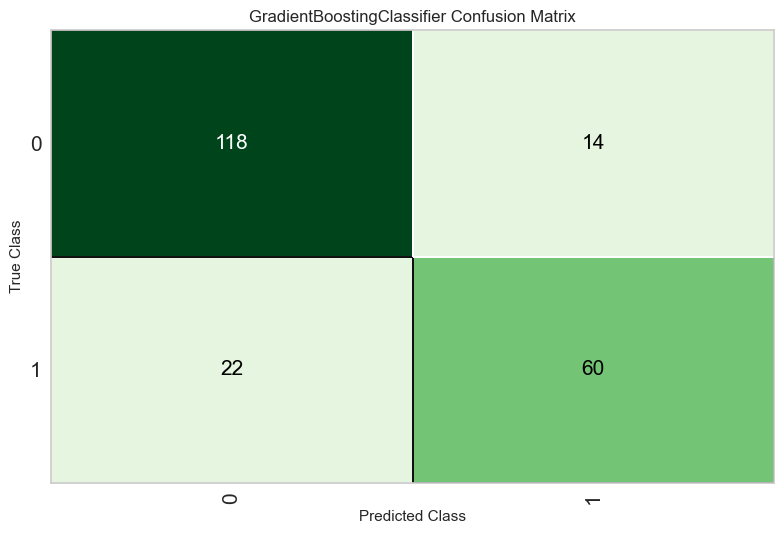

In [8]:
# Karmaşıklık matrisi
plot_model(ayarli, plot="confusion_matrix")

In [9]:
# Modelin hiç görmediği test setinde tahmin
tahminler = predict_model(ayarli, data=test)
tahminler[["Survived", "prediction_label", "prediction_score"]].head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.7877,0.8088,0.6522,0.7627,0.7031,0.5395,0.5435


,Survived,prediction_label,prediction_score
565,0,0,0.8940
160,0,0,0.9086
553,1,0,0.9283
860,0,0,0.9203
241,1,1,0.7227


In [10]:
# Bütün veriyle son kez eğit ve kaydet (ön işleme adımları da dosyaya dahil)
final = finalize_model(ayarli)
save_model(final, "titanic_model")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Pclass', 'Age', 'SibSp', 'Parch',
                                              'Fare'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None, include=['Sex...
                                             criterion='friedman_mse', init=None,
                                             lear

## 3. SHAP: Model neden bu kararı verdi?

SHAP her değişkenin tahmini **ne kadar artırdığını ya da azalttığını** hesaplıyor.
Ağaç tabanlı modellerde en hızlı yöntem `TreeExplainer`. Bu yüzden burada PyCaret ile bir **Random Forest** modeli kuruyoruz.

In [11]:
import shap

rf = create_model("rf", verbose=False)

# PyCaret'in ön işlemeden geçirdiği test verisi
X_test = get_config("X_test_transformed")

explainer = shap.TreeExplainer(rf)

# Sınıflandırmada iki sınıf var; 1 = hayatta kaldı sınıfını alıyoruz
shap_values = explainer(X_test)[..., 1]

### Genel tablo: Beeswarm

Değişkenler önem sırasına göre dizili. Her nokta bir yolcu. Kırmızı yüksek değeri, mavi düşük değeri gösteriyor.
Sağa doğru giden noktalar hayatta kalma ihtimalini artırıyor, sola doğru gidenler azaltıyor.

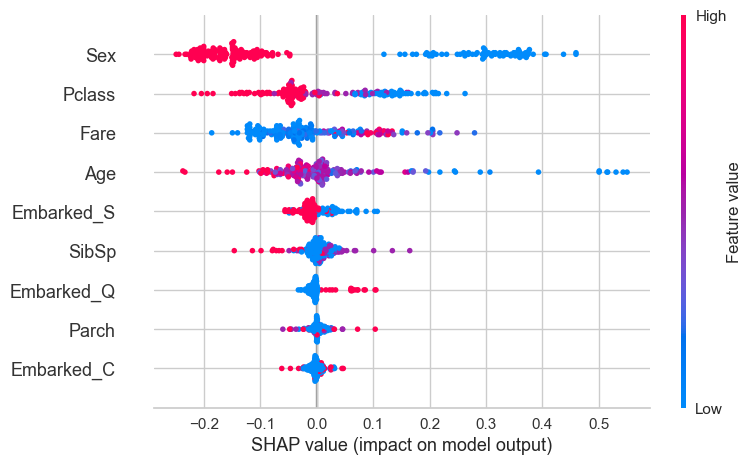

In [12]:
shap.plots.beeswarm(shap_values)

### Tek bir yolcu: Waterfall

Model bu yolcu için neden bu tahmini yaptı? Başlangıç değerinden (ortalama tahmin) son tahmine kadar her değişkenin katkısını adım adım gösteriyor.

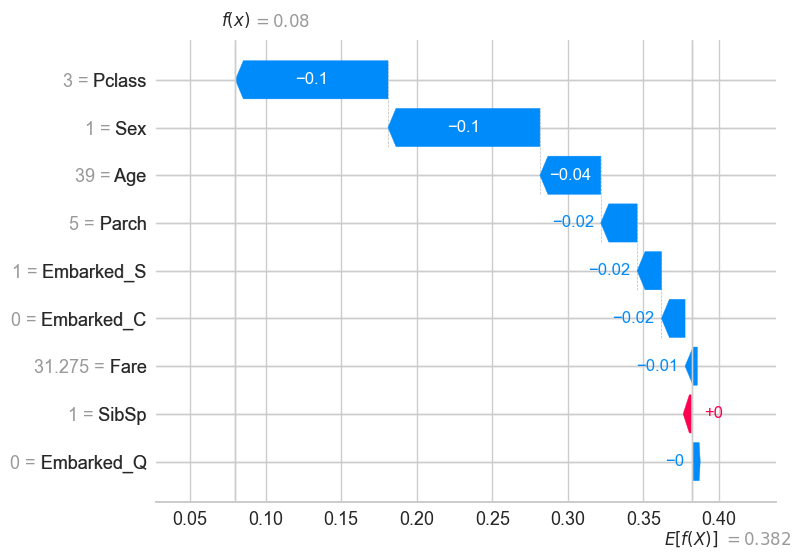

In [13]:
shap.plots.waterfall(shap_values[0])

## Özet

| Adım | Kütüphane | Kazancın |
|---|---|---|
| Veriyi tanı | Sweetviz | Dakikalar içinde tam EDA raporu |
| Modeli kur | PyCaret | Birkaç satırla uçtan uca pipeline |
| Modeli açıkla | SHAP | Tahminin nedenini grafikle anlatabilirsin |